In [29]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports (THIS WAS MISSING)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.preprocessing import load_data, prepare_features_target, split_data, print_data_info
from src.models import create_models, train_and_evaluate, compare_models, get_best_model

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 50)
print("Data Preparation")
print("=" * 50)

df = load_data()
X, y = prepare_features_target(df)
X_train, X_test, y_train, y_test = split_data(X, y)

print_data_info(X_train, X_test, y_train, y_test)

Data Preparation
Training set size: 16512 houses
Test set size: 4128 houses
Training features: 8

Train/Test ratio: 4.00:1


In [30]:
print("=" * 50)
print("Model Training")
print("=" * 50)

models = create_models()
results = train_and_evaluate(models, X_train, X_test, y_train, y_test)

for name, metrics in results.items():
    print(f"\n{name}")
    print(f"  Train MAE:  {metrics['train_mae']:.3f}")
    print(f"  Test MAE:   {metrics['test_mae']:.3f}")
    print(f"  Train RMSE: {metrics['train_rmse']:.3f}")
    print(f"  Test RMSE:  {metrics['test_rmse']:.3f}")
    print(f"  Train R2:   {metrics['train_r2']:.3f}")
    print(f"  Test R2:    {metrics['test_r2']:.3f}")


Model Training

Linear Regression
  Train MAE:  0.529
  Test MAE:   0.533
  Train RMSE: 0.720
  Test RMSE:  0.746
  Train R2:   0.613
  Test R2:    0.576

Decision Tree
  Train MAE:  0.000
  Test MAE:   0.455
  Train RMSE: 0.000
  Test RMSE:  0.704
  Train R2:   1.000
  Test R2:    0.622

Random Forest
  Train MAE:  0.122
  Test MAE:   0.328
  Train RMSE: 0.188
  Test RMSE:  0.505
  Train R2:   0.974
  Test R2:    0.805

Gradient Boosting
  Train MAE:  0.357
  Test MAE:   0.372
  Train RMSE: 0.511
  Test RMSE:  0.542
  Train R2:   0.805
  Test R2:    0.776


In [31]:
comparison_df = compare_models(results)
best_model_name, best_model = get_best_model(results, comparison_df)

print("=" * 50)
print("Model Comparison")
print("=" * 50)
print(comparison_df)
print(f"\nBest model: {best_model_name}")

best_predictions = results[best_model_name]['y_test_pred']


Model Comparison
                      Train MAE  Test MAE    Train RMSE  Test RMSE  Train R2  \
Random Forest      1.220567e-01  0.327543  1.879562e-01   0.505340  0.973573   
Gradient Boosting  3.566327e-01  0.371643  5.106939e-01   0.542215  0.804898   
Decision Tree      4.593655e-17  0.454679  3.218326e-16   0.703729  1.000000   
Linear Regression  5.286284e-01  0.533200  7.196757e-01   0.745581  0.612551   

                    Test R2  
Random Forest      0.805123  
Gradient Boosting  0.775645  
Decision Tree      0.622076  
Linear Regression  0.575788  

Best model: Random Forest


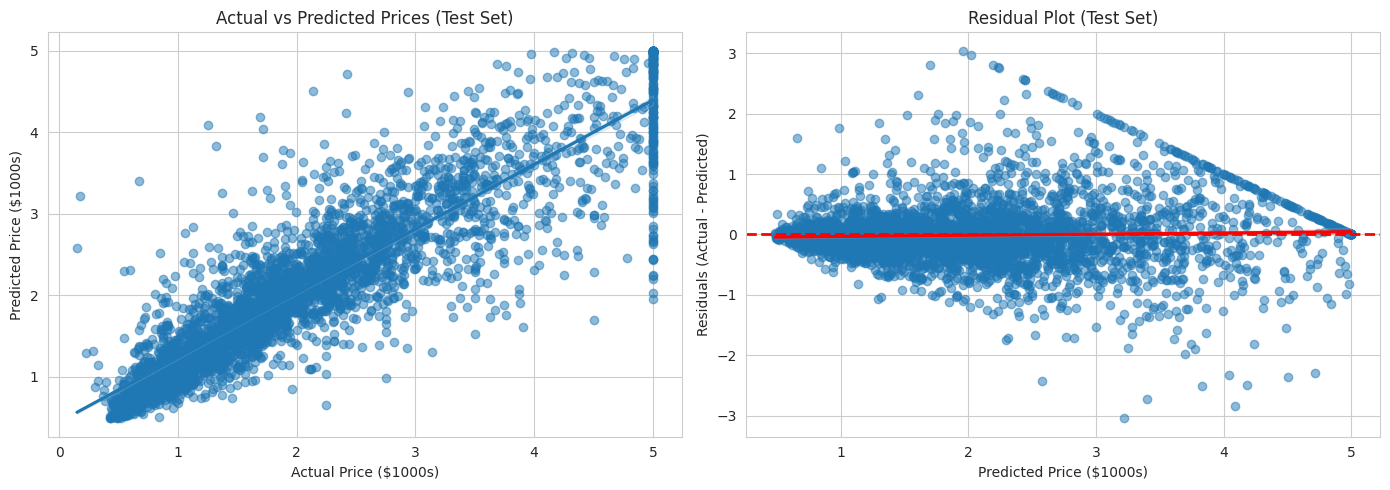

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x=y_test, y=best_predictions, ax=axes[0], scatter_kws={'alpha': 0.5})
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].set_title('Actual vs Predicted Prices (Test Set)')

residuals = y_test - best_predictions
sns.regplot(x=best_predictions, y=residuals, ax=axes[1], scatter_kws={'alpha': 0.5}, line_kws={'color': 'r'})
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($1000s)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot (Test Set)')

plt.tight_layout()
plt.show()


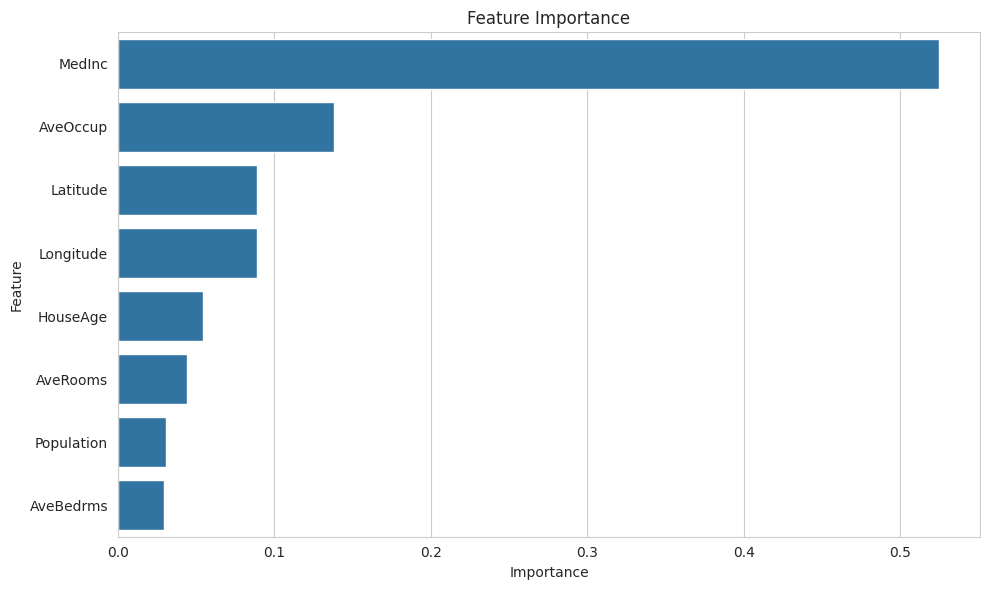

In [33]:
import pandas as pd
import numpy as np

feature_names = X.columns

if hasattr(best_model, 'coef_'):
    importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.coef_,
        'Abs_Importance': np.abs(best_model.coef_)
    }).sort_values('Abs_Importance', ascending=False)
    values = importance['Importance']
    labels = importance['Feature']
    title = 'Feature Importance (Linear Regression Coefficients)'
elif hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    values = importance['Importance']
    labels = importance['Feature']
    title = 'Feature Importance'
else:
    importance = None

if importance is not None:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=values, y=labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [34]:
# Hyperparameter Tuning for Random Forest (Reduce Overfitting)
from sklearn.model_selection import GridSearchCV

print("="*50)
print("Hyperparameter Tuning")
print("="*50)

# Define hyperparameter grid to test
param_grid = {
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6]
}

# Create base Random Forest
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)

# Grid Search with cross-validation
print("\nSearching best hyperparameters...")
grid_search = GridSearchCV(
    rf_base, 
    param_grid, 
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Get best model
best_rf = grid_search.best_estimator_

print(f"\n Best hyperparameters found:")
print(f"  max_depth: {grid_search.best_params_['max_depth']}")
print(f"  min_samples_split: {grid_search.best_params_['min_samples_split']}")
print(f"  min_samples_leaf: {grid_search.best_params_['min_samples_leaf']}")
print(f"\n  Best CV R2 Score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
y_train_pred_tuned = best_rf.predict(X_train)
y_test_pred_tuned = best_rf.predict(X_test)

train_r2_tuned = r2_score(y_train, y_train_pred_tuned)
test_r2_tuned = r2_score(y_test, y_test_pred_tuned)
test_mae_tuned = mean_absolute_error(y_test, y_test_pred_tuned)
test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))

print(f"\n{'='*50}")
print("TUNED RANDOM FOREST RESULTS")
print(f"{'='*50}")
print(f"Train R2: {train_r2_tuned:.4f}")
print(f"Test R2:  {test_r2_tuned:.4f}")
print(f"Overfit Gap: {train_r2_tuned - test_r2_tuned:.4f}")
print(f"\nTest MAE:  ${test_mae_tuned:.3f}k")
print(f"Test RMSE: ${test_rmse_tuned:.3f}k")

Hyperparameter Tuning

Searching best hyperparameters...

 Best hyperparameters found:
  max_depth: 15
  min_samples_split: 5
  min_samples_leaf: 2

  Best CV R2 Score: 0.8030

TUNED RANDOM FOREST RESULTS
Train R2: 0.9424
Test R2:  0.8027
Overfit Gap: 0.1397

Test MAE:  $0.331k
Test RMSE: $0.509k


In [35]:
# More agressive tuning to further reduce overfitting

print("\n" + "="*50)
print("Agressive tuning (Focus on Overfitting)")
print("="*50)

# More restrictive parameters
param_grid_aggressive = {
    'max_depth': [5, 8, 10, 12],  # Shallower trees 
    'min_samples_split': [10, 20, 30],  # Force more samples to split
    'min_samples_leaf': [5, 10, 15],  # Force more samples in leaves
    'max_features': ['sqrt', 'log2']  # Use fewer features per split
}

rf_base = RandomForestRegressor(n_estimators=100, random_state=42)

print("\nSearching aggressive hyperparameters...")
grid_search_aggressive = GridSearchCV(
    rf_base, 
    param_grid_aggressive, 
    cv=5,
    scoring='r2',
    n_jobs=-2  # Leave 1 core free
)

grid_search_aggressive.fit(X_train, y_train)

# Get best model
best_rf_aggressive = grid_search_aggressive.best_estimator_

print(f"\n Best hyperparameters found:")
print(f"  max_depth: {grid_search_aggressive.best_params_['max_depth']}")
print(f"  min_samples_split: {grid_search_aggressive.best_params_['min_samples_split']}")
print(f"  min_samples_leaf: {grid_search_aggressive.best_params_['min_samples_leaf']}")
print(f"  max_features: {grid_search_aggressive.best_params_['max_features']}")
print(f"\n  Best CV R2 Score: {grid_search_aggressive.best_score_:.4f}")

# Evaluate
y_train_pred_agg = best_rf_aggressive.predict(X_train)
y_test_pred_agg = best_rf_aggressive.predict(X_test)

train_r2_agg = r2_score(y_train, y_train_pred_agg)
test_r2_agg = r2_score(y_test, y_test_pred_agg)
test_mae_agg = mean_absolute_error(y_test, y_test_pred_agg)
test_rmse_agg = np.sqrt(mean_squared_error(y_test, y_test_pred_agg))

print(f"\n{'='*50}")
print("AGGRESSIVE TUNED RANDOM FOREST")
print(f"{'='*50}")
print(f"Train R2: {train_r2_agg:.4f}")
print(f"Test R2:  {test_r2_agg:.4f}")
print(f"Overfit Gap: {train_r2_agg - test_r2_agg:.4f}")
print(f"\nTest MAE:  ${test_mae_agg:.3f}k")
print(f"Test RMSE: ${test_rmse_agg:.3f}k")

# Compare all three
print(f"\n{'='*50}")
print("COMPARISON: Original vs Tuned vs Aggressive")
print(f"{'='*50}")

comparison_all = pd.DataFrame({
    'Model': ['Original RF', 'Tuned RF', 'Aggressive RF'],
    'Train R2': [0.973573, train_r2_tuned, train_r2_agg],
    'Test R2': [0.805123, test_r2_tuned, test_r2_agg],
    'Overfit Gap': [0.168450, train_r2_tuned - test_r2_tuned, train_r2_agg - test_r2_agg],
    'Test MAE': [0.327543, test_mae_tuned, test_mae_agg]
})

print("\n" + comparison_all.to_string(index=False))


Agressive tuning (Focus on Overfitting)

Searching aggressive hyperparameters...

 Best hyperparameters found:
  max_depth: 12
  min_samples_split: 10
  min_samples_leaf: 5
  max_features: log2

  Best CV R2 Score: 0.7987

AGGRESSIVE TUNED RANDOM FOREST
Train R2: 0.8740
Test R2:  0.7929
Overfit Gap: 0.0811

Test MAE:  $0.348k
Test RMSE: $0.521k

COMPARISON: Original vs Tuned vs Aggressive

        Model  Train R2  Test R2  Overfit Gap  Test MAE
  Original RF  0.973573 0.805123     0.168450  0.327543
     Tuned RF  0.942371 0.802658     0.139713  0.330546
Aggressive RF  0.873954 0.792892     0.081062  0.347917
